#Data cleaning process

In [5]:
import pandas as pd
df=pd.read_csv(r"C:\Users\WELCOME\Downloads\Online Retail.csv",encoding='latin-1')
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(df.shape)

(532621, 9)


In [6]:
df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]
df=df[df['CustomerID'].notnull()]
print(df.shape)

(397884, 9)


In [7]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
print(df[['Quantity','UnitPrice','TotalPrice']].head())

   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [9]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Month']=df['InvoiceDate'].dt.to_period('M')
monthly_sales=df.groupby('Month')['TotalPrice'].sum()
print(monthly_sales.head())

Month
2010-12    572713.890
2011-01    569445.040
2011-02    447137.350
2011-03    595500.760
2011-04    469200.361
Freq: M, Name: TotalPrice, dtype: float64


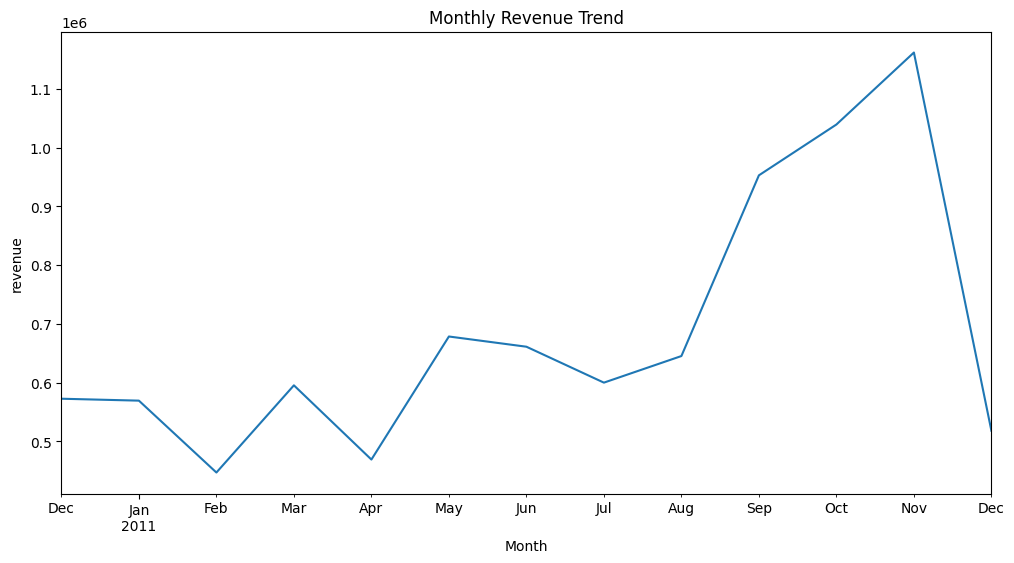

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('revenue')
plt.show()

In [11]:
top_customers=df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


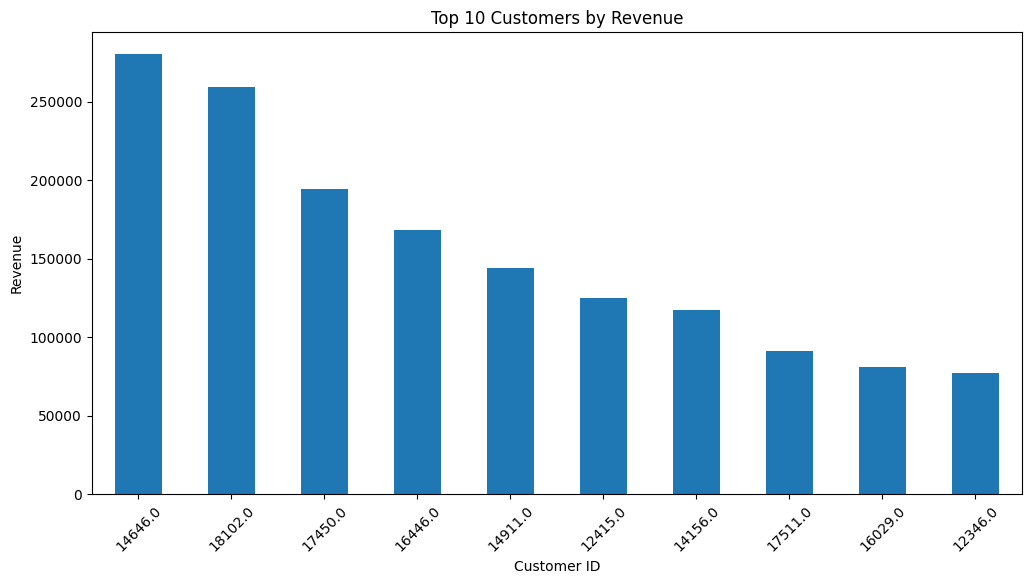

In [14]:
plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [17]:
top_products=df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


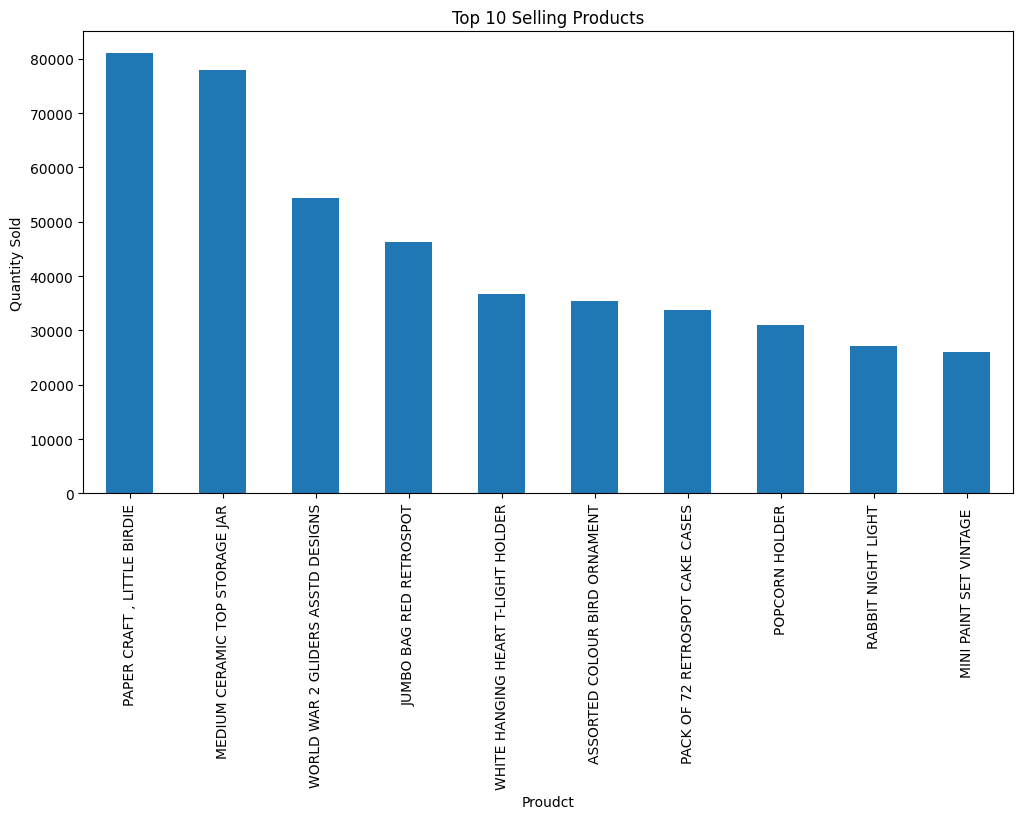

In [18]:
plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Proudct')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)
plt.show()

In [20]:
top_countries=df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_countries)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64


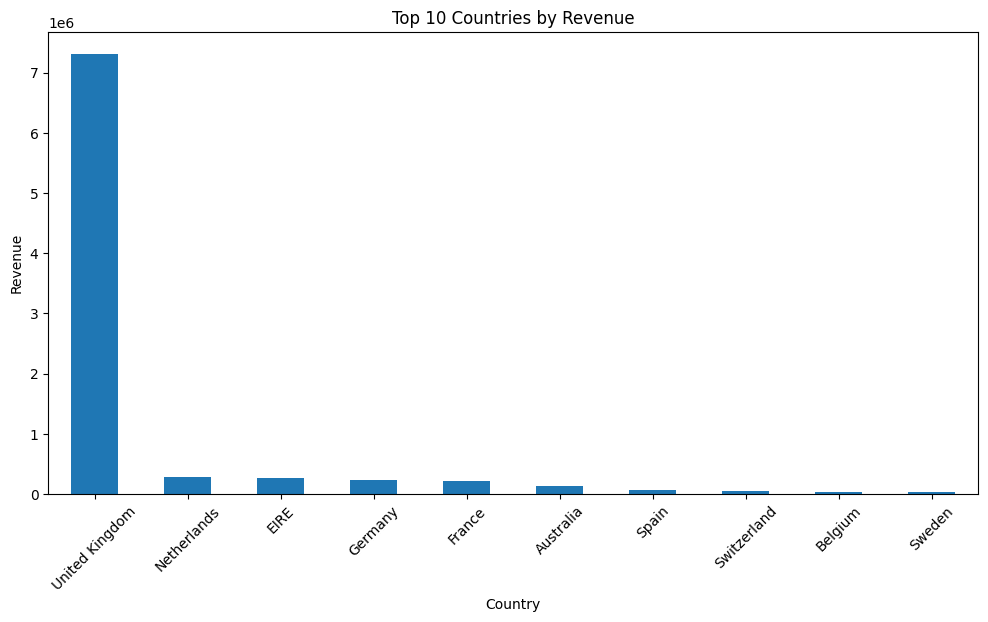

In [24]:
plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [27]:
snapshot_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [31]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2        182   4310.00
12348.0          75         31   1797.24
12349.0          19         73   1757.55
12350.0         310         17    334.40


In [32]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_retail.csv', index=False)
print(f"File saved! Rows: {len(df):,}")

File saved! Rows: 397,884


In [33]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
print(df[['Quantity','UnitPrice','TotalPrice']].head())

   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [34]:
df.to_csv('../data/processed/cleaned_retail.csv',index=False)
print("Updated CSV saved successfully!")

Updated CSV saved successfully!


In [35]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_retail.csv', index=False)
print(f"Saved! Rows: {len(df):,}")

Saved! Rows: 397,884


In [38]:
import os
import pandas as pd

# Load raw data - CSV file
df = pd.read_csv(
    r'D:\E-Commerce-Customer-Analytics\data\Online Retail.csv',
    encoding='latin-1',
    dtype={'CustomerID': str}
)

print(f"Raw data loaded: {len(df):,} rows")

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Clean the data
df = df.drop_duplicates()
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df.dropna(subset=['Description'], inplace=True)

# Create new columns
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Save cleaned file
os.makedirs(
    r'D:\E-Commerce-Customer-Analytics\data\processed',
    exist_ok=True
)

df.to_csv(
    r'D:\E-Commerce-Customer-Analytics\data\processed\cleaned_retail.csv',
    index=False
)

print(f"✅ File saved!")
print(f"Clean rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Raw data loaded: 541,909 rows
✅ File saved!
Clean rows: 530,104
Columns: ['index', 'InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Hour', 'DayOfWeek', 'YearMonth']
